In [1]:
import os
os.environ["JOBLIB_MULTIPROCESSING"] = "0"
os.environ["LOKY_MAX_CPU_COUNT"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from dowhy.gcm.falsify import falsify_graph
from dowhy.gcm.util.general import set_random_seed
from matplotlib.backends.backend_pdf import PdfPages
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import joblib

import pingouin as pg
import warnings
warnings.filterwarnings('ignore')

In [2]:
set_random_seed(1332)

GRAPH_FILE = "PC_causal_graph_270411.gml"
DATA_FILE = "dataset_270411_final_ingles.csv"

print("Cargando grafo...")

g = nx.read_gml(GRAPH_FILE)
g = nx.DiGraph(g)

print(f"Nodos: {g.number_of_nodes()}")
print(f"Aristas: {g.number_of_edges()}")

print("Verificando si el grafo es DAG...")

g_dag = g.copy()

while not nx.is_directed_acyclic_graph(g_dag):
    cycle = list(nx.simple_cycles(g_dag))[0]
    u, v = cycle[-1], cycle[0]

    print(f"Eliminando arista {u} -> {v}")

    g_dag.remove_edge(u, v)

print("DAG válido obtenido")


Cargando grafo...
Nodos: 16
Aristas: 68
Verificando si el grafo es DAG...
Eliminando arista SCHOOL_TYPE -> SCHOOL_DEPENDENCY
Eliminando arista INCOME_PERCENTILE -> MOTHER_EDUCATION
Eliminando arista FATHER_EDUCATION -> SCHOOL_DEPENDENCY
DAG válido obtenido


In [3]:
nodos=list(g_dag.nodes())

In [4]:
A=nx.to_numpy_array(g_dag).round(1)

In [5]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

In [6]:
vcenter=0
vmin=np.min(A)
vmax=np.max(A)

In [7]:
nodos

['GRADUATION_YEAR',
 'GRADE_PERCENTILE',
 'SCORE_RANKING',
 'AVERAGE_MATH_LANG',
 'GENDER',
 'HOW_MANY_WORK',
 'HOW_MANY_STUDY',
 'INCOME_PERCENTILE',
 'MOTHER_EDUCATION',
 'FATHER_EDUCATION',
 'PREVIOUS_ADMISSION',
 'SCHOOL_TYPE',
 'SCHOOL_DEPENDENCY',
 'WORK',
 'RURAL',
 'SCORE_NEM']

<Axes: >

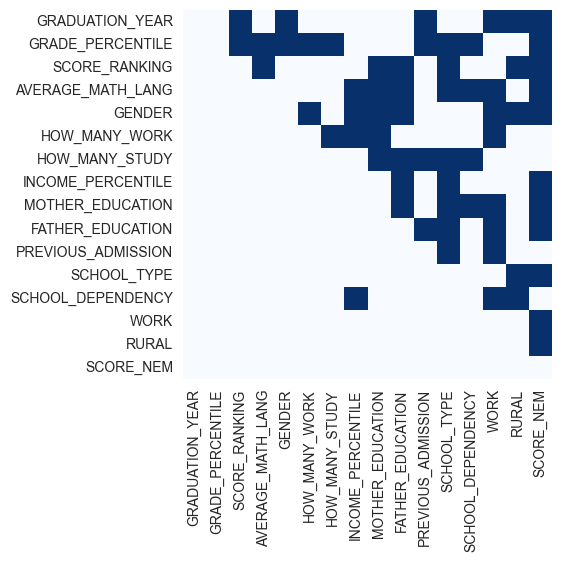

In [8]:
sns.set_style("white")
sns.heatmap(np.where(A!=0,1,0),square=True,cmap="Blues",
            xticklabels=nodos,yticklabels=nodos,cbar=False)

In [9]:
#número de permutaciones
import math
math.factorial(16)

20922789888000

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from dowhy.gcm.falsify import FalsifyConst, falsify_graph, plot_local_insights, run_validations, apply_suggestions
from dowhy.gcm.independence_test.generalised_cov_measure import generalised_cov_based
from dowhy.gcm.util import plot
from dowhy.gcm.util.general import set_random_seed
from dowhy.gcm.ml import SklearnRegressionModel

In [11]:
data = pd.read_csv(f"dataset_270411_final_ingles.csv", sep=';')

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270411 entries, 0 to 270410
Data columns (total 16 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   GRADUATION_YEAR     270411 non-null  int64  
 1   SCORE_NEM           270411 non-null  int64  
 2   GRADE_PERCENTILE    270411 non-null  int64  
 3   SCORE_RANKING       270411 non-null  int64  
 4   AVERAGE_MATH_LANG   270411 non-null  float64
 5   GENDER              270411 non-null  int64  
 6   HOW_MANY_WORK       270411 non-null  int64  
 7   HOW_MANY_STUDY      270411 non-null  int64  
 8   INCOME_PERCENTILE   270411 non-null  int64  
 9   MOTHER_EDUCATION    270411 non-null  int64  
 10  FATHER_EDUCATION    270411 non-null  int64  
 11  PREVIOUS_ADMISSION  270411 non-null  int64  
 12  SCHOOL_TYPE         270411 non-null  int64  
 13  SCHOOL_DEPENDENCY   270411 non-null  int64  
 14  WORK                270411 non-null  int64  
 15  RURAL               270411 non-nul

In [13]:
g_dag.nodes(data=True)

NodeDataView({'GRADUATION_YEAR': {}, 'GRADE_PERCENTILE': {}, 'SCORE_RANKING': {}, 'AVERAGE_MATH_LANG': {}, 'GENDER': {}, 'HOW_MANY_WORK': {}, 'HOW_MANY_STUDY': {}, 'INCOME_PERCENTILE': {}, 'MOTHER_EDUCATION': {}, 'FATHER_EDUCATION': {}, 'PREVIOUS_ADMISSION': {}, 'SCHOOL_TYPE': {}, 'SCHOOL_DEPENDENCY': {}, 'WORK': {}, 'RURAL': {}, 'SCORE_NEM': {}})

In [14]:
if not nx.is_directed_acyclic_graph(g_dag):
    print("Error: el gráfico proporcionado no es un DAG")
else:
    print("DAG VALIDO")

DAG VALIDO


In [15]:
from dowhy import gcm

In [136]:
np.random.seed(0)

In [137]:
causal_model = gcm.InvertibleStructuralCausalModel(g_dag)
gcm.auto.assign_causal_mechanisms(causal_model, data, quality=gcm.auto.AssignmentQuality.BETTER)
gcm.fit(causal_model, data)

Fitting causal mechanism of node SCORE_NEM: 100%|██████████| 16/16 [00:18<00:00,  1.15s/it]         


In [138]:
joblib.dump(causal_model, 'causal_model.joblib')

['causal_model.joblib']

In [139]:
causal_model = joblib.load('causal_model.joblib')

In [140]:
strength = gcm.arrow_strength(causal_model, 'SCORE_NEM')
strength

{('AVERAGE_MATH_LANG', 'SCORE_NEM'): 23.603930839999986,
 ('FATHER_EDUCATION', 'SCORE_NEM'): 0.8704179276932077,
 ('GENDER', 'SCORE_NEM'): 2.010481248966944,
 ('GRADE_PERCENTILE', 'SCORE_NEM'): 44.18961211818182,
 ('GRADUATION_YEAR', 'SCORE_NEM'): 8.582283930000001,
 ('INCOME_PERCENTILE', 'SCORE_NEM'): 5.96147929230769,
 ('MOTHER_EDUCATION', 'SCORE_NEM'): 1.2609248478552264,
 ('RURAL', 'SCORE_NEM'): 2.565569139008618,
 ('SCHOOL_TYPE', 'SCORE_NEM'): 19.470700885964916,
 ('SCORE_RANKING', 'SCORE_NEM'): 8502.292434569445,
 ('WORK', 'SCORE_NEM'): 0.42050119217424964}

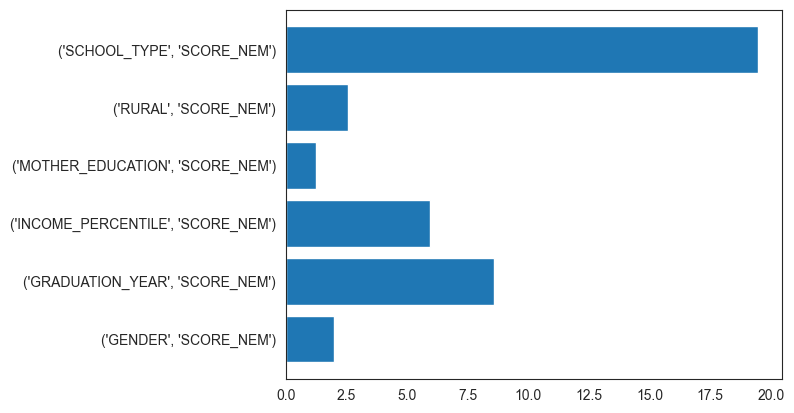

In [179]:
x=[]
y=[]
for key in strength:
    if key not in [('AVERAGE_MATH_LANG', 'SCORE_NEM'),
                   ('SCORE_RANKING', 'SCORE_NEM'),
                   ('GRADE_PERCENTILE', 'SCORE_NEM'),
                   ('WORK','SCORE_NEM'),
                   ('FATHER_EDUCATION','SCORE_NEM')]:
        x.append(key)
        y.append(strength[key])
plt.barh(list(map(str,x)),y);

In [142]:
strength2 = gcm.arrow_strength(causal_model, 'SCHOOL_TYPE')
strength2

{('AVERAGE_MATH_LANG', 'SCHOOL_TYPE'): 0.05077059943181817,
 ('FATHER_EDUCATION', 'SCHOOL_TYPE'): 0.041715524774774755,
 ('GRADE_PERCENTILE', 'SCHOOL_TYPE'): 0.05437922435897436,
 ('HOW_MANY_STUDY', 'SCHOOL_TYPE'): 0.0038360434782608553,
 ('INCOME_PERCENTILE', 'SCHOOL_TYPE'): 0.01535209183673468,
 ('MOTHER_EDUCATION', 'SCHOOL_TYPE'): 0.05176183991228071,
 ('PREVIOUS_ADMISSION', 'SCHOOL_TYPE'): 0.010354145833333325,
 ('SCORE_RANKING', 'SCHOOL_TYPE'): 0.04088668589743589}

In [143]:
contributions = gcm.intrinsic_causal_influence(causal_model, 'SCORE_NEM')
contributions

Evaluating set functions...: 100%|██████████| 351/351 [08:09<00:00,  1.40s/it]


{'GRADUATION_YEAR': 366.9933898588547,
 'GRADE_PERCENTILE': 6963.64412579468,
 'SCORE_RANKING': 3587.2085731022917,
 'GENDER': -3.223971783990253,
 'AVERAGE_MATH_LANG': 94.86769298977939,
 'HOW_MANY_WORK': 1.9928073382487443,
 'HOW_MANY_STUDY': -0.30688061695477364,
 'MOTHER_EDUCATION': 0.3887792761005307,
 'SCHOOL_DEPENDENCY': -0.03059858396980102,
 'INCOME_PERCENTILE': -1.5285291127808966,
 'FATHER_EDUCATION': -2.427207044957293,
 'PREVIOUS_ADMISSION': -8.748848867590198e-14,
 'SCHOOL_TYPE': -4.269556387117668,
 'WORK': -0.12944620271397148,
 'RURAL': -3.0449042991387363,
 'SCORE_NEM': 293.7540163132993}

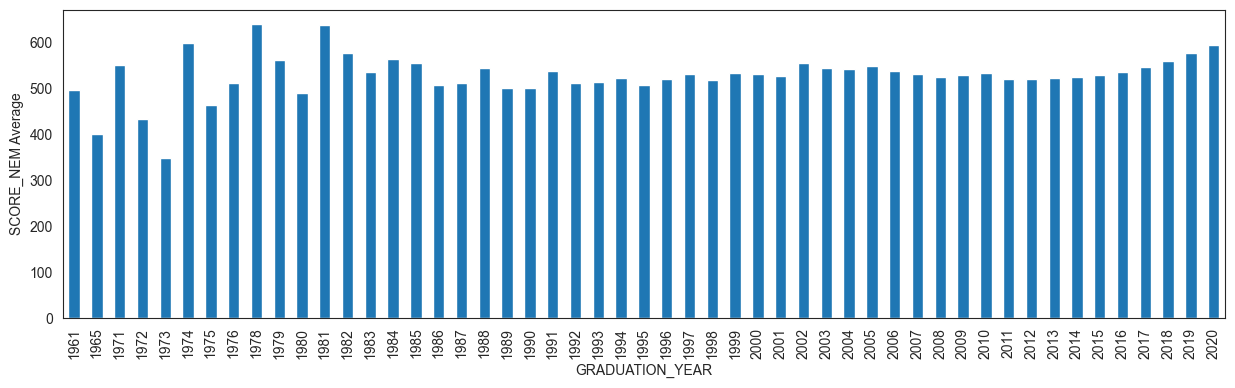

In [171]:
fig, axes = plt.subplots(1,1)
fig.set_size_inches(15, 4)
data.groupby("GRADUATION_YEAR")["SCORE_NEM"].mean().plot.bar(ax=axes)
axes.set_ylabel("SCORE_NEM Average");

In [172]:
res=pg.kruskal(data=data, dv='SCORE_NEM', between='GRADUATION_YEAR',detailed=True)
res

,Source,ddof1,H,p-unc
Kruskal,GRADUATION_YEAR,50,8088.62875,0.0


In [173]:
res=pg.kruskal(data=data, dv='SCORE_NEM', between='SCHOOL_TYPE',detailed=True)
res

,Source,ddof1,H,p-unc
Kruskal,SCHOOL_TYPE,1,7318.839988,0.0


In [174]:
data.groupby("SCHOOL_TYPE")["SCORE_NEM"].mean()

SCHOOL_TYPE
0    593.377734
1    550.972063
Name: SCORE_NEM, dtype: float64

In [175]:
res=pg.kruskal(data=data, dv='SCORE_NEM', between='GENDER',detailed=True)
res

,Source,ddof1,H,p-unc
Kruskal,GENDER,1,5330.851597,0.0


In [176]:
data.groupby("SCHOOL_TYPE")["GENDER"].mean()

SCHOOL_TYPE
0    1.550683
1    1.541847
Name: GENDER, dtype: float64

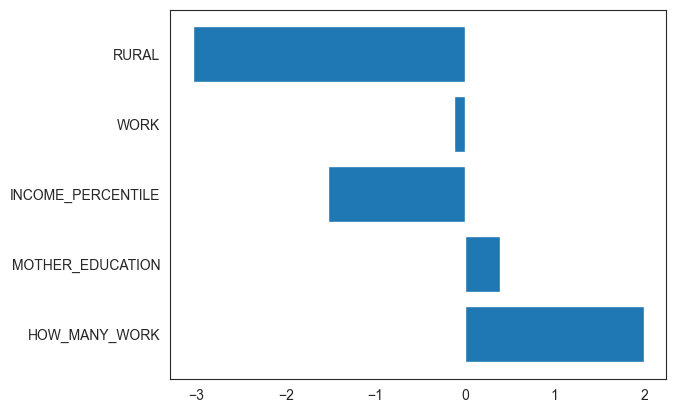

In [177]:
x=[]
y=[]
for key in contributions:
    if key not in ['GRADE_PERCENTILE','SCORE_RANKING','AVERAGE_MATH_LANG',
                   'SCORE_NEM','GRADUATION_YEAR','FATHER_EDUCATION',
                   'SCHOOL_DEPENDENCY',
                   'PREVIOUS_ADMISSION','HOW_MANY_STUDY','GENDER','SCHOOL_TYPE']:
        x.append(key)
        y.append(contributions[key])
plt.barh(list(map(str,x)),y);

In [178]:
res=pg.kruskal(data=data, dv='SCORE_NEM', between='WORK',detailed=True)
res

,Source,ddof1,H,p-unc
Kruskal,WORK,1,3954.746525,0.0


In [69]:
posthoc = pg.pairwise_tests(
    data=data, 
    between='WORK', 
    dv='SCORE_NEM',
    parametric=False, 
    padjust='none',
    effsize="cohen"
)

In [70]:
posthoc

,Contrast,A,B,Paired,Parametric,U-val,alternative,p-unc,cohen
0,WORK,0,1,False,False,2.919342e+09,two-sided,0.0,0.495817


In [40]:
data.groupby("WORK")["SCORE_NEM"].mean()

WORK
0    586.090954
1    532.969754
Name: SCORE_NEM, dtype: float64

In [71]:
res=pg.kruskal(data=data, dv='SCORE_NEM', between='HOW_MANY_WORK',detailed=True)
res

,Source,ddof1,H,p-unc
Kruskal,HOW_MANY_WORK,7,661.802275,1.181449e-138


In [72]:
norm_test = pg.normality(data=data, dv='SCORE_NEM', group='MOTHER_EDUCATION')
hom_test = pg.homoscedasticity(data=data, dv='SCORE_NEM', group='MOTHER_EDUCATION')
#For repeated measures ANOVA
#sph_test = pg.sphericity(data=data, dv='SCORE_NEM', within='time', subject='MOTHER_EDUCATION')
print(norm_test)
print(hom_test)

                         W          pval  normal
MOTHER_EDUCATION                                
6                 0.993586  1.556121e-20   False
5                 0.994225  1.640009e-35   False
4                 0.993275  1.344594e-20   False
7                 0.993245  2.370894e-48   False
1                 0.990104  2.758880e-07   False
9                 0.992954  9.135811e-36   False
11                0.983099  2.757062e-53   False
2                 0.986423  4.268376e-06   False
10                0.991176  4.877353e-40   False
8                 0.991709  9.111684e-29   False
12                0.964352  1.899222e-35   False
3                 0.995282  1.808085e-01    True
               W          pval  equal_var
levene  21.74497  5.348215e-45      False


In [73]:
res=pg.kruskal(data=data, dv='SCORE_NEM', between='FATHER_EDUCATION',detailed=True)
res

,Source,ddof1,H,p-unc
Kruskal,FATHER_EDUCATION,11,14846.521432,0.0


In [74]:
res=pg.kruskal(data=data, dv='SCORE_NEM', between='MOTHER_EDUCATION',detailed=True)
res

,Source,ddof1,H,p-unc
Kruskal,MOTHER_EDUCATION,11,13211.874683,0.0


In [75]:
norm_test = pg.normality(data=data, dv='SCORE_NEM', group='INCOME_PERCENTILE')
hom_test = pg.homoscedasticity(data=data, dv='SCORE_NEM', group='INCOME_PERCENTILE')
#For repeated measures ANOVA
#sph_test = pg.sphericity(data=data, dv='SCORE_NEM', within='time', subject='MOTHER_EDUCATION')
print(norm_test)
print(hom_test)

                          W          pval  normal
INCOME_PERCENTILE                                
3                  0.992502  6.779734e-39   False
8                  0.991255  1.352613e-33   False
1                  0.993478  2.470424e-42   False
2                  0.993404  4.359108e-36   False
4                  0.993148  1.281545e-32   False
9                  0.988590  3.194558e-37   False
7                  0.991462  4.906386e-31   False
10                 0.973455  2.196519e-49   False
6                  0.992375  5.913557e-29   False
5                  0.992330  1.087033e-30   False
                W          pval  equal_var
levene  27.676713  1.638722e-48      False


In [76]:
res=pg.kruskal(data=data, dv='SCORE_NEM', between='INCOME_PERCENTILE',detailed=True)
res

,Source,ddof1,H,p-unc
Kruskal,INCOME_PERCENTILE,9,8557.65179,0.0


In [77]:
data.groupby("INCOME_PERCENTILE")["SCORE_NEM"].agg(["mean","std"]).round(2)

,mean,std
INCOME_PERCENTILE,,
1,562.93,104.73
2,571.71,105.32
3,577.60,105.63
4,580.40,104.98
5,584.96,105.41
6,588.89,105.11
7,587.14,106.10
8,578.78,108.36
9,602.95,109.88


In [78]:
h_stat = res.loc['Kruskal', 'H']
n = data['SCORE_NEM'].count()  # Total sample size
k = data['MOTHER_EDUCATION'].nunique() 

Common guidelines for interpreting these effect sizes 
$(\eta ^{2} are:)$

$(Small: 0.01 \leq \text{effect} < 0.06
Moderate: 0.06 \leq \text{effect} < 0.14
Large: \text{effect} \geq 0.14)$

In [79]:
epsilon_sq = h_stat / ((n**2 - 1) / (n + 1))
print(f"Epsilon-squared: {epsilon_sq:.4f}")

Epsilon-squared: 0.0316


In [80]:
eta_sq = (h_stat - k + 1) / (n - k)
print(f"Eta-squared: {eta_sq:.4f}")

Eta-squared: 0.0316


In [81]:
norm_test = pg.normality(data=data, dv='SCORE_NEM', group='RURAL')
hom_test = pg.homoscedasticity(data=data, dv='SCORE_NEM', group='RURAL')
print(norm_test,hom_test)

              W          pval  normal
RURAL                                
0      0.991688  1.674127e-61   False
1      0.991590  4.858951e-56   False                W      pval  equal_var
levene  4.584006  0.032273      False


In [82]:
res=pg.kruskal(data=data, dv='SCORE_NEM', between='RURAL',detailed=True)
res

,Source,ddof1,H,p-unc
Kruskal,RURAL,1,101.334215,7.770194e-24


In [83]:
data.groupby("RURAL")["SCORE_NEM"].mean()

RURAL
0    584.322063
1    579.885463
Name: SCORE_NEM, dtype: float64

In [84]:
data.groupby("RURAL")["SCORE_NEM"].count()

RURAL
0    161686
1    108725
Name: SCORE_NEM, dtype: int64

In [85]:
h_stat = res.loc['Kruskal', 'H']
n = data['SCORE_NEM'].count()  # Total sample size
k = data['WORK'].nunique() 

In [86]:
epsilon_sq = h_stat / ((n**2 - 1) / (n + 1))
print(f"Epsilon-squared: {epsilon_sq:.4f}")

Epsilon-squared: 0.0004


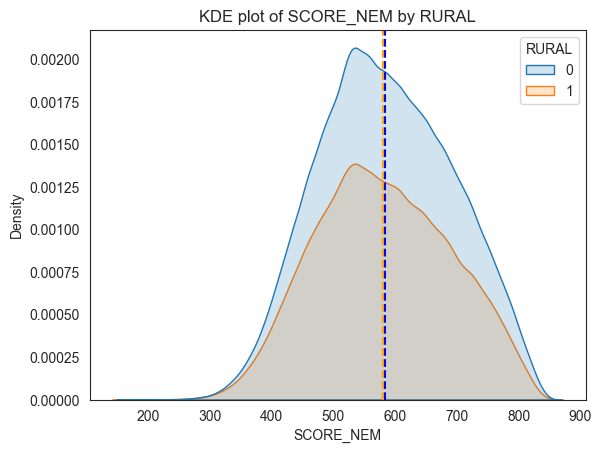

In [87]:
group_means = data.groupby('RURAL')['SCORE_NEM'].mean()
ax = sns.kdeplot(data=data, x='SCORE_NEM', 
                 hue='RURAL', common_norm=True, fill=True, alpha=0.2)
plt.axvline(group_means[0], color='blue', linestyle='--')
plt.axvline(group_means[1], color='orange', linestyle='--')
plt.title('KDE plot of SCORE_NEM by RURAL')
plt.show()


In [88]:
norm_test = pg.normality(data=data, dv='SCORE_NEM', group='WORK')
hom_test = pg.homoscedasticity(data=data, dv='SCORE_NEM', group='WORK')
print(norm_test,hom_test)

             W          pval  normal
WORK                                
1     0.987852  3.225661e-36   False
0     0.991722  1.370963e-67   False                 W          pval  equal_var
levene  65.033511  7.393242e-16      False


In [89]:
res=pg.kruskal(data=data, dv='SCORE_NEM', between='WORK',detailed=True)
res

,Source,ddof1,H,p-unc
Kruskal,WORK,1,3954.746525,0.0


In [90]:
h_stat = res.loc['Kruskal', 'H']
n = data['SCORE_NEM'].count()  # Total sample size
k = data['WORK'].nunique() 

In [91]:
epsilon_sq = h_stat / ((n**2 - 1) / (n + 1))
print(f"Epsilon-squared: {epsilon_sq:.4f}")

Epsilon-squared: 0.0146


In [180]:
data.groupby("WORK")["SCORE_NEM"].agg(["mean","std"]).round(2)

,mean,std
WORK,,
0,586.09,107.30
1,532.97,104.91


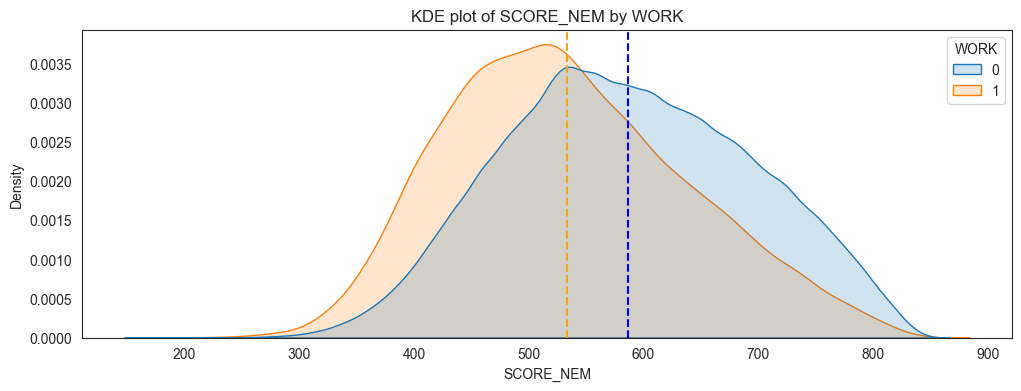

In [170]:
fig, ax = plt.subplots(1,1)
fig.set_size_inches(12, 4)
group_means = data.groupby('WORK')['SCORE_NEM'].mean()
sns.kdeplot(data=data, x='SCORE_NEM', 
            hue='WORK', common_norm=False, fill=True, alpha=0.2, ax=ax)
plt.axvline(group_means[0], color='blue', linestyle='--')
plt.axvline(group_means[1], color='orange', linestyle='--')
plt.title('KDE plot of SCORE_NEM by WORK')
plt.show()

In [93]:
norm_test = pg.normality(data=data, dv='SCORE_NEM', group='SCHOOL_TYPE')
hom_test = pg.homoscedasticity(data=data, dv='SCORE_NEM', group='SCHOOL_TYPE')
print(norm_test,hom_test)

                    W          pval  normal
SCHOOL_TYPE                                
0            0.990586  3.369861e-67   False
1            0.993855  5.232888e-44   False                   W           pval  equal_var
levene  1098.147624  2.542500e-240      False


In [94]:
res=pg.kruskal(data=data, dv='SCORE_NEM', between='SCHOOL_TYPE',detailed=True)
res

,Source,ddof1,H,p-unc
Kruskal,SCHOOL_TYPE,1,7318.839988,0.0


In [95]:
h_stat = res.loc['Kruskal', 'H']
n = data['SCORE_NEM'].count()  # Total sample size
k = data['SCHOOL_TYPE'].nunique() 

In [96]:
epsilon_sq = h_stat / ((n**2 - 1) / (n + 1))
print(f"Epsilon-squared: {epsilon_sq:.4f}")

Epsilon-squared: 0.0271


In [97]:
observed=data.query("RURAL==1")

In [98]:
simulacion=gcm.counterfactual_samples(
    causal_model,
    {'RURAL': lambda x: 0},
    observed_data=observed)

In [99]:
len(simulacion)

108725

579.8854633249023 581.6292756955622


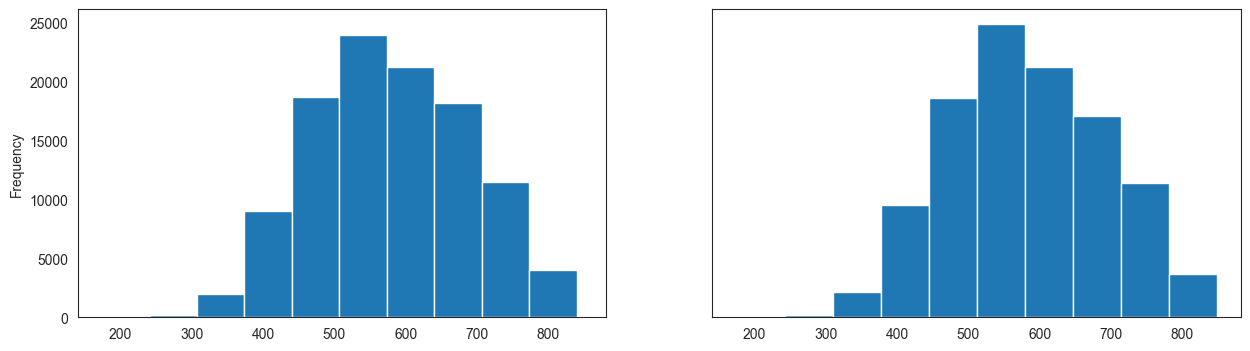

In [100]:
fig, axes = plt.subplots(1,2,sharex=True,sharey=True)
fig.set_size_inches(15, 4)
observed["SCORE_NEM"].plot.hist(ax=axes[0])
simulacion["SCORE_NEM"].plot.hist(ax=axes[1])
print(observed["SCORE_NEM"].mean(),simulacion["SCORE_NEM"].mean())

In [101]:
observed["SIMULATED"]=0
simulacion["SIMULATED"]=1
consolidado=pd.concat([observed,simulacion])

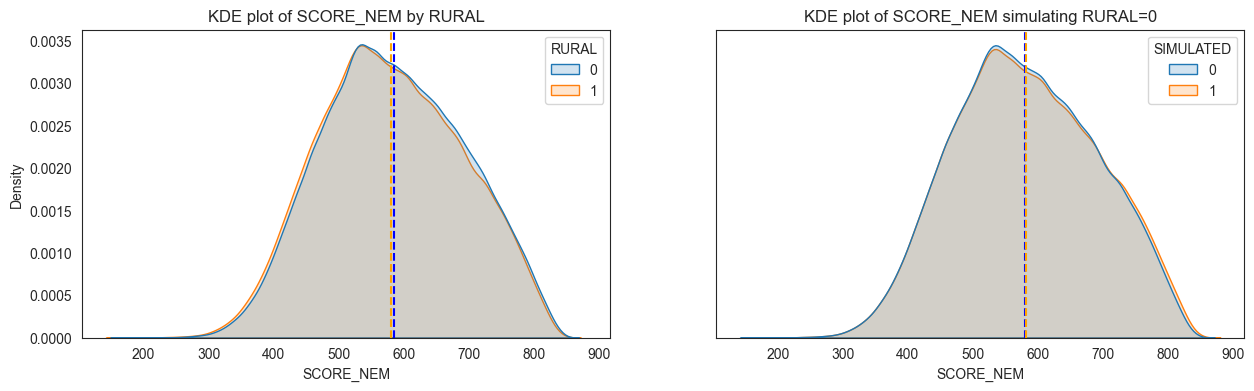

In [102]:
fig, axes = plt.subplots(1,2,sharex=True,sharey=True)
fig.set_size_inches(15, 4)

group_means = data.groupby('RURAL')['SCORE_NEM'].mean()
sns.kdeplot(data=data, x='SCORE_NEM', hue='RURAL', common_norm=False, fill=True, alpha=0.2,ax=axes[0])
axes[0].axvline(group_means[0], color='blue', linestyle='--')
axes[0].axvline(group_means[1], color='orange', linestyle='--')
axes[0].set_title('KDE plot of SCORE_NEM by RURAL');

group_means = consolidado.groupby('SIMULATED')['SCORE_NEM'].mean()
sns.kdeplot(data=consolidado, x='SCORE_NEM', hue='SIMULATED', common_norm=False, fill=True, alpha=0.2,ax=axes[1])
axes[1].axvline(group_means[0], color='blue', linestyle='--')
axes[1].axvline(group_means[1], color='orange', linestyle='--')
axes[1].set_title('KDE plot of SCORE_NEM simulating RURAL=0');

In [103]:
group_means

SIMULATED
0    579.885463
1    581.629276
Name: SCORE_NEM, dtype: float64

In [104]:
res=pg.kruskal(data=consolidado, dv='SCORE_NEM', between='SIMULATED',detailed=True)
res

,Source,ddof1,H,p-unc
Kruskal,SIMULATED,1,12.687206,0.000368


In [105]:
h_stat = res.loc['Kruskal', 'H']
n = consolidado['SCORE_NEM'].count()  # Total sample size
k = consolidado['SIMULATED'].nunique() 

In [106]:
epsilon_sq = h_stat / ((n**2 - 1) / (n + 1))
print(f"Epsilon-squared: {epsilon_sq:.4f}")

Epsilon-squared: 0.0001


SIMULATED
0    586.090954
1    584.947445
Name: SCORE_NEM, dtype: float64 SIMULATED
0    107.296414
1    106.643670
Name: SCORE_NEM, dtype: float64             Source  ddof1          H     p-unc
Kruskal  SIMULATED      1  22.978814  0.000002


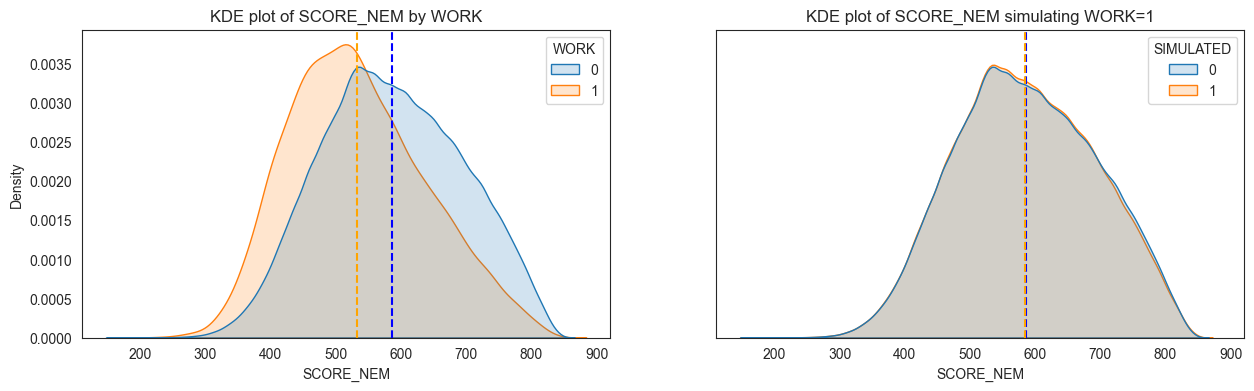

In [153]:
observed=data.query("WORK==0")
simulacion=gcm.counterfactual_samples(
    causal_model,
    {'WORK': lambda x: 1},
    observed_data=observed)
observed["SIMULATED"]=0
simulacion["SIMULATED"]=1
consolidado=pd.concat([observed,simulacion])
fig, axes = plt.subplots(1,2,sharex=True,sharey=True)
fig.set_size_inches(15, 4)

group_means = data.groupby('WORK')['SCORE_NEM'].mean()
sns.kdeplot(data=data, x='SCORE_NEM', hue='WORK', common_norm=False, fill=True, alpha=0.2,ax=axes[0])
axes[0].axvline(group_means[0], color='blue', linestyle='--')
axes[0].axvline(group_means[1], color='orange', linestyle='--')
axes[0].set_title('KDE plot of SCORE_NEM by WORK');

group_means = consolidado.groupby('SIMULATED')['SCORE_NEM'].mean()
group_sd = consolidado.groupby('SIMULATED')['SCORE_NEM'].std()
sns.kdeplot(data=consolidado, x='SCORE_NEM', hue='SIMULATED', common_norm=False, fill=True, alpha=0.2,ax=axes[1])
axes[1].axvline(group_means[0], color='blue', linestyle='--')
axes[1].axvline(group_means[1], color='orange', linestyle='--')
axes[1].set_title('KDE plot of SCORE_NEM simulating WORK=1');

res=pg.kruskal(data=consolidado, dv='SCORE_NEM', between='SIMULATED',detailed=True)
print(group_means,group_sd,res)

SIMULATED
0    593.377734
1    582.042779
Name: SCORE_NEM, dtype: float64             Source  ddof1            H          p-unc
Kruskal  SIMULATED      1  1042.419898  1.081181e-228


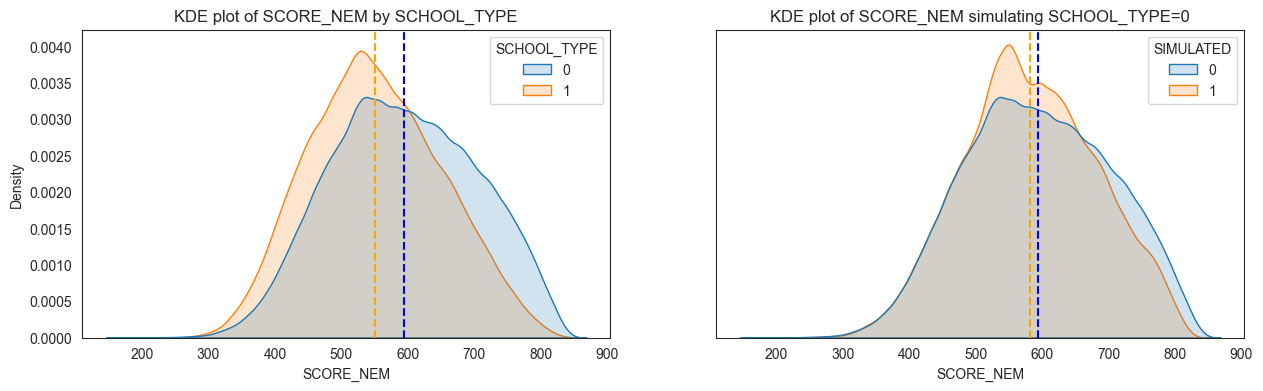

In [128]:
observed=data.query("SCHOOL_TYPE==0")
simulacion=gcm.counterfactual_samples(
    causal_model,
    {'SCHOOL_TYPE': lambda x: 1},
    observed_data=observed)
observed["SIMULATED"]=0
simulacion["SIMULATED"]=1
consolidado=pd.concat([observed,simulacion])
fig, axes = plt.subplots(1,2,sharex=True,sharey=True)
fig.set_size_inches(15, 4)

group_means = data.groupby('SCHOOL_TYPE')['SCORE_NEM'].mean()
sns.kdeplot(data=data, x='SCORE_NEM', hue='SCHOOL_TYPE', common_norm=False, fill=True, alpha=0.2,ax=axes[0])
axes[0].axvline(group_means[0], color='blue', linestyle='--')
axes[0].axvline(group_means[1], color='orange', linestyle='--')
axes[0].set_title('KDE plot of SCORE_NEM by SCHOOL_TYPE');

group_means = consolidado.groupby('SIMULATED')['SCORE_NEM'].mean()
sns.kdeplot(data=consolidado, x='SCORE_NEM', hue='SIMULATED', common_norm=False, fill=True, alpha=0.2,ax=axes[1])
axes[1].axvline(group_means[0], color='blue', linestyle='--')
axes[1].axvline(group_means[1], color='orange', linestyle='--')
axes[1].set_title('KDE plot of SCORE_NEM simulating SCHOOL_TYPE=0');


res=pg.kruskal(data=consolidado, dv='SCORE_NEM', between='SIMULATED',detailed=True)
print(group_means,res)


OLS model fitted successfully.
                            OLS Regression Results                            
Dep. Variable:              SCORE_NEM   R-squared:                       0.694
Model:                            OLS   Adj. R-squared:                  0.694
Method:                 Least Squares   F-statistic:                 6.803e+04
Date:                Tue, 19 May 2026   Prob (F-statistic):               0.00
Time:                        21:55:51   Log-Likelihood:            -1.4897e+06
No. Observations:              270411   AIC:                         2.980e+06
Df Residuals:                  270401   BIC:                         2.980e+06
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const 

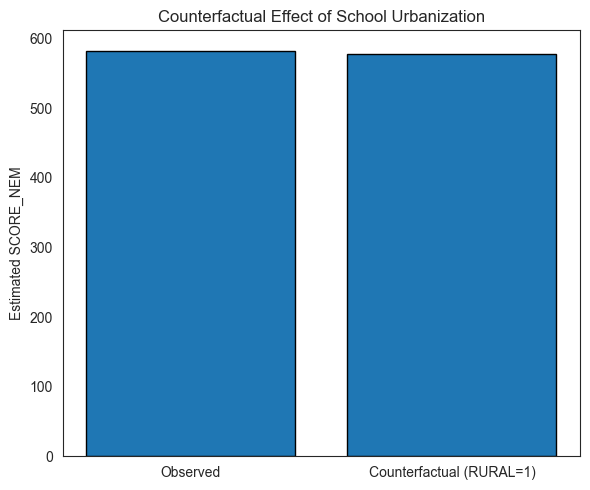

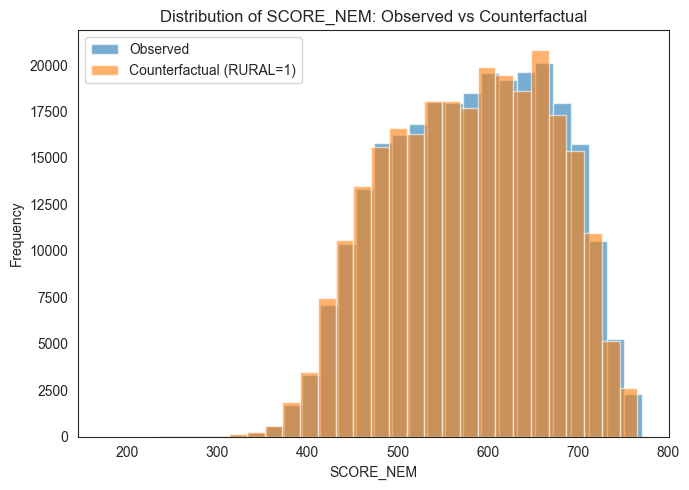

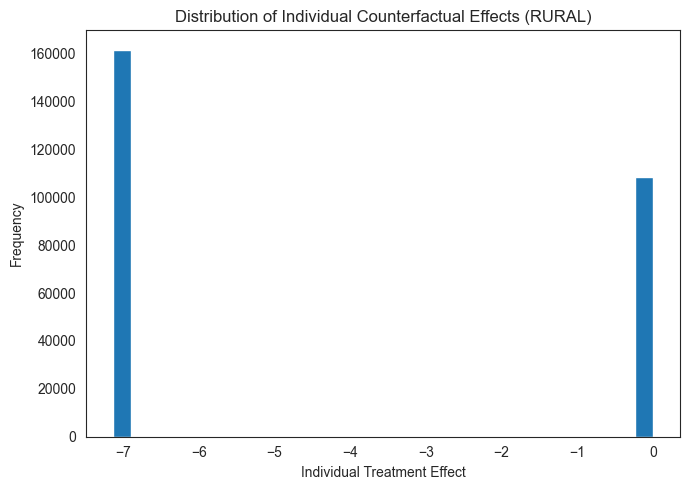


All figures generated successfully.


In [150]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy import stats

# =====================================
# 1. Load dataset
# =====================================
df = pd.read_csv("dataset_270411_final_ingles.csv", sep=";")

# =====================================
# 2. Define variables
# =====================================
Y_VAR = "SCORE_NEM"

X_VARS = [
    "SCHOOL_TYPE",
    "GRADUATION_YEAR",
    "GENDER",
    "MOTHER_EDUCATION",
    "INCOME_PERCENTILE",
    "HOW_MANY_WORK",
    "WORK",
    "RURAL",
    "GRADE_PERCENTILE"
]

df_model = df[X_VARS]
df_model[Y_VAR]=df[Y_VAR]

X = sm.add_constant(df_model[X_VARS])
y = df_model[Y_VAR]

# =====================================
# 3. Fit OLS model
# =====================================
model = sm.OLS(y, X).fit()

print("\nOLS model fitted successfully.")
print(model.summary())

# =====================================
# 4. Observed predictions
# =====================================
df_model["SCORE_NEM_observed"] = model.predict(X)

# =====================================
# 5. Counterfactual intervention:
#    RURAL = 0  ---> RURAL = 1
# =====================================
X_cf = X.copy()

# Apply intervention only to rural students
X_cf.loc[X_cf["RURAL"] == 0, "RURAL"] = 1

df_model["SCORE_NEM_counterfactual"] = model.predict(X_cf)

# =====================================
# 6. Individual treatment effect
# =====================================
df_model["Individual_Effect"] = (
    df_model["SCORE_NEM_counterfactual"] - df_model["SCORE_NEM_observed"]
)

# Save results
df_model[
    ["RURAL", "SCORE_NEM_observed", "SCORE_NEM_counterfactual", "Individual_Effect"]
].to_csv(
    "counterfactual_RURAL_0_to_1.csv",
    sep=";",
    index=False
)

print("\nCounterfactual results saved to 'counterfactual_RURAL_0_to_1.csv'.")

# =====================================
# 7. Aggregate effects
# =====================================
avg_observed = df_model["SCORE_NEM_observed"].mean()
avg_counterfactual = df_model["SCORE_NEM_counterfactual"].mean()
avg_effect = df_model["Individual_Effect"].mean()

print("\nAverage Effects:")
print(f"Observed mean SCORE_NEM: {avg_observed:.3f}")
print(f"Counterfactual mean SCORE_NEM (RURAL=1): {avg_counterfactual:.3f}")
print(f"Average Treatment Effect (ATE): {avg_effect:.3f}")

# =====================================
# 8. Comparative figures (paper-ready)
# =====================================

# --- Figure 1: Mean comparison ---
plt.figure(figsize=(6, 5))
plt.bar(
    ["Observed", "Counterfactual (RURAL=1)"],
    [avg_observed, avg_counterfactual],
    edgecolor="black"
)
plt.ylabel("Estimated SCORE_NEM")
plt.title("Counterfactual Effect of School Urbanization")
plt.tight_layout()
plt.savefig("Figure_RURAL_Observed_vs_Counterfactual.png", dpi=300)
plt.show()

# --- Figure 2: Distribution comparison ---
plt.figure(figsize=(7, 5))
plt.hist(
    df_model["SCORE_NEM_observed"],
    bins=30,
    alpha=0.6,
    label="Observed"
)
plt.hist(
    df_model["SCORE_NEM_counterfactual"],
    bins=30,
    alpha=0.6,
    label="Counterfactual (RURAL=1)"
)
plt.xlabel("SCORE_NEM")
plt.ylabel("Frequency")
plt.title("Distribution of SCORE_NEM: Observed vs Counterfactual")
plt.legend()
plt.tight_layout()
plt.savefig("Figure_RURAL_Distribution_Comparison.png", dpi=300)
plt.show()

# --- Figure 3: Individual effects ---
plt.figure(figsize=(7, 5))
plt.hist(df_model["Individual_Effect"], bins=30)
plt.xlabel("Individual Treatment Effect")
plt.ylabel("Frequency")
plt.title("Distribution of Individual Counterfactual Effects (RURAL)")
plt.tight_layout()
plt.savefig("Figure_RURAL_Individual_Effects.png", dpi=300)
plt.show()

print("\nAll figures generated successfully.")


OLS model fitted successfully.
                            OLS Regression Results                            
Dep. Variable:              SCORE_NEM   R-squared:                       0.694
Model:                            OLS   Adj. R-squared:                  0.694
Method:                 Least Squares   F-statistic:                 6.803e+04
Date:                Tue, 19 May 2026   Prob (F-statistic):               0.00
Time:                        21:54:58   Log-Likelihood:            -1.4897e+06
No. Observations:              270411   AIC:                         2.980e+06
Df Residuals:                  270401   BIC:                         2.980e+06
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const 

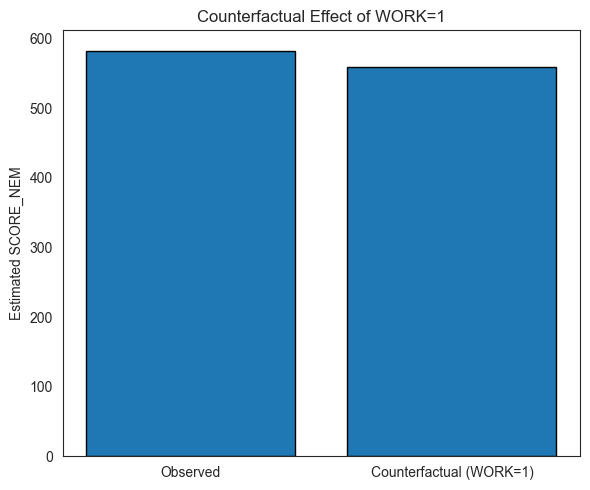

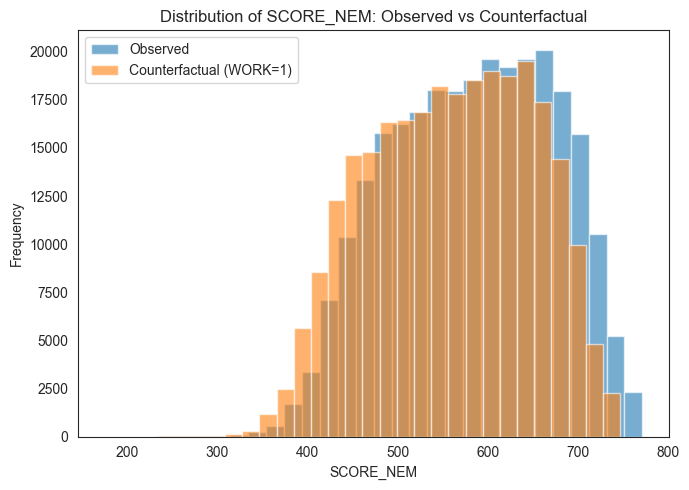

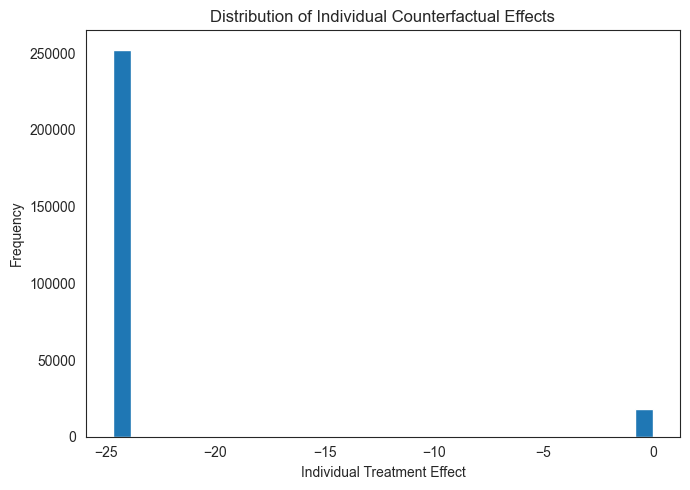


All figures generated successfully.


In [149]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

Y_VAR = "SCORE_NEM"

X_VARS = [
    "SCHOOL_TYPE",
    "GRADUATION_YEAR",
    "GENDER",
    "MOTHER_EDUCATION",
    "INCOME_PERCENTILE",
    "HOW_MANY_WORK",
    "WORK",
    "RURAL",
    "GRADE_PERCENTILE"
]

df_model = df[X_VARS]
df_model[Y_VAR]=df[Y_VAR]

X = sm.add_constant(df_model[X_VARS])
y = df_model[Y_VAR]

model = sm.OLS(y, X).fit()

print("\nOLS model fitted successfully.")
print(model.summary())

df_model["SCORE_NEM_observed"] = model.predict(X)
X_cf = X.copy()
X_cf.loc[X_cf["WORK"] == 0, "WORK"] = 1
df_model["SCORE_NEM_counterfactual"] = model.predict(X_cf)

df_model["Individual_Effect"] = (
    df_model["SCORE_NEM_counterfactual"] - df_model["SCORE_NEM_observed"]
)

df_model[
    ["WORK", "SCORE_NEM_observed", "SCORE_NEM_counterfactual", "Individual_Effect"]
].to_csv(
    "counterfactual_WORK_0_to_1.csv",
    sep=";",
    index=False
)

print("\nCounterfactual results saved to 'counterfactual_WORK_0_to_1.csv'.")


avg_observed = df_model["SCORE_NEM_observed"].mean()
avg_counterfactual = df_model["SCORE_NEM_counterfactual"].mean()
avg_effect = df_model["Individual_Effect"].mean()

print("\nAverage Effects:")
print(f"Observed mean SCORE_NEM: {avg_observed:.3f}")
print(f"Counterfactual mean SCORE_NEM (WORK=1): {avg_counterfactual:.3f}")
print(f"Average Treatment Effect (ATE): {avg_effect:.3f}")


plt.figure(figsize=(6, 5))
plt.bar(
    ["Observed", "Counterfactual (WORK=1)"],
    [avg_observed, avg_counterfactual],
    edgecolor="black"
)
plt.ylabel("Estimated SCORE_NEM")
plt.title("Counterfactual Effect of WORK=1")
plt.tight_layout()
plt.savefig("Figure_WORK_Observed_vs_Counterfactual.png", dpi=300)
plt.show()

plt.figure(figsize=(7, 5))
plt.hist(
    df_model["SCORE_NEM_observed"],
    bins=30,
    alpha=0.6,
    label="Observed"
)
plt.hist(
    df_model["SCORE_NEM_counterfactual"],
    bins=30,
    alpha=0.6,
    label="Counterfactual (WORK=1)"
)
plt.xlabel("SCORE_NEM")
plt.ylabel("Frequency")
plt.title("Distribution of SCORE_NEM: Observed vs Counterfactual")
plt.legend()
plt.tight_layout()
plt.savefig("Figure_WORK_Distribution_Comparison.png", dpi=300)
plt.show()

plt.figure(figsize=(7, 5))
plt.hist(df_model["Individual_Effect"], bins=30)
plt.xlabel("Individual Treatment Effect")
plt.ylabel("Frequency")
plt.title("Distribution of Individual Counterfactual Effects")
plt.tight_layout()
plt.savefig("Figure_WORK_Individual_Effects.png", dpi=300)
plt.show()

print("\nAll figures generated successfully.")
